# 04_01 · 波动观测量与预测目标

本书读取01的分钟价格、02的BPV季节因子和03的采样映射，构造后续建模与评价使用的**已实现波动观测量**。这里不拟合模型，也不生成预测值。

## 先分清本书实际构造的两类区间

| 输出 | 起点与终点 | 当前用途 |
|---|---|---|
| 采样区间 RV／BPV | 03映射中的前一个采样点 → 当前采样点 | 与价格收益逐区间对应；供事件模型拟合及下一采样步评价 |
| 未来十五分钟 RV／BPV | 原始分钟表中的整数分钟末 → 同时段十五分钟后 | 供共同期限的HAR训练及十五分钟评价；所有采样方案共用这张标签表 |

**当前十五分钟标签不是从每个重采样价格点起算。** 积分函数可以处理分钟内部的小数端点，但目前十五分钟起点筛选使用的是原始分钟末。事件预测到十五分钟的转换属于04_04，不在本书进行。

## 怎样顺序阅读和运行

1. 导入公共依赖。
2. 阅读“按区间累加分钟贡献”的独立函数：先看输入、坐标例子，再看前缀积分。
3. 阅读公共构造函数：函数内部用编号注释串起完整数据处理过程。
4. 执行构造函数，得到内存中的公共观测量。
5. 查看来源核对、区间资格和分布诊断。

第2、3节运行时只定义函数，**第4节的显式调用才开始读取数据和构造观测量**。后续三本按顺序加载带有 `observation-kernel` 标记的公共依赖和函数定义，再自行调用同一入口；不会执行本书的展示单元。

## 公共结果与单位

| 返回键 | 一行／一项表示什么 |
|---|---|
| `minute_measures_df` | 一个原始分钟的log收益、RV／BPV贡献和历史季节因子 |
| `events_by_fold` | 每个fold的一张采样区间表，保留区间身份、指标、资格和排除原因 |
| `targets_15m_df` | 一个共同整数分钟起点的十五分钟真实标签和季节暴露 |
| `activity_df` | 03提供的全合约分钟活动，供04_04转换使用 |
| `manifest` | 输入来源、版本摘要、fold边界与当前计算口径 |
| `schemas` | 三张波动观测表的局部Arrow字段、类型与可空约束 |
| `compatibility_df`、`fold_diagnostics_df` | 本书展示的来源兼容性与区间覆盖摘要 |

RV是原始一分钟log收益的平方之和；BPV是相邻绝对log收益乘积乘以π/2后的贡献之和。部分分钟按覆盖比例计入，**不除以区间长度，也不取平方根**；这些量在方差尺度上。源分钟i占据交易坐标 `[i,i+1]`，分钟末坐标是i+1，休市不增加交易坐标。

区间收益沿用03的分钟内插值价格与全快照双向复权；RV／BPV使用原始同合约、同时段分钟收益。它们是不同统计量，当前结果属于既有回溯价格输入下的探索性研究。低成本观测量只在内存构造，不另存中间数据文件。

方法依据：[Barndorff-Nielsen & Shephard (2004)](https://www.nuffield.ox.ac.uk/economics/Papers/2003/w18/eric.pdf)、[Andersen et al. (2003)](https://public.econ.duke.edu/Papers/Other/Bollerslev/Volatility.pdf)、[Patton (2011)](https://public.econ.duke.edu/~ap172/Patton_vol_proxies_JoE_2011.pdf)。论文提供方法依据，不代表已经验证本IM短区间实现的统计性质。

**阶段阅读导航**：[01_01 主力连续价格](01_01_im_main_continuous.ipynb) → [02_01 BPV季节因子](02_01_im_bpv_intraday_seasonality.ipynb)（[02_02 窗口比较](02_02_im_bpv_window_comparison.ipynb)）→ [03_01 采样时钟与价格](03_01_im_clock_resampling.ipynb)（[03_02 时钟诊断](03_02_im_clock_comparison_diagnostics.ipynb)）→ [04_01 波动观测量](04_01_im_volatility_observations.ipynb) → [04_02 每日拟合](04_02_im_volatility_model_fitting.ipynb) → [04_03 下一采样步预测](04_03_im_next_step_volatility_forecasting.ipynb)／[04_04 未来15分钟预测](04_04_im_15m_volatility_forecasting.ipynb)。括号中的比较与诊断本用于查看对应阶段结果，不是下一阶段的数据生成依赖；最后两本预测相互独立。

## 1. 公共依赖

这一格只导入后面两个函数需要的库。

In [2]:
# 公共依赖：运行这一格只导入库，不读取研究数据。
import pathlib
import json
import hashlib
import time
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

## 2. 独立操作：按区间累加分钟贡献

函数的第一个输入是一列**已经算好的分钟贡献**。第二、第三个输入共同指定要汇总哪些区间。下面先定义这个通用操作；它会在构造函数的数值检查、事件RV／BPV、十五分钟标签和季节暴露计算中反复调用。

In [3]:
def integrate_minute_measure(minute_values, start_coordinates, end_coordinates):
    """把一列分钟贡献按给定区间累加，返回每个区间的贡献总和。

    输入
    ----
    minute_values : 一维数组，按01源分钟的全局行号排列
        每行已经是一个分钟贡献，不是价格。计算RV时传入 r_m ** 2；
        计算BPV时传入 (pi/2) * abs(r_m) * abs(r_{m-1})。
        BPV记在分钟m这一行，但计算它实际使用了相邻两分钟的收益。
        本函数不计算收益，也不判断传入的是RV、BPV还是季节因子。
    start_coordinates, end_coordinates : 等长的一维数组
        第k对数值定义第k个区间。源分钟i占据坐标[i, i+1]，
        i+0.5表示该分钟中间，i+1表示该分钟结束；它们不是时间戳。
        坐标由调用方提供：可以来自采样映射，也可以来自十五分钟目标。

    输出与约定
    ----------
    返回与区间数量等长的float数组：完整分钟计入整份贡献，
    部分分钟按覆盖比例计入。结果是总和，不除以区间时长。
    例如minute_values=[2, 4]、区间[0.5, 1.5]，返回0.5*2+0.5*4=3。
    这是把分钟贡献视为分钟内均匀分配的近似，不增加真实秒级信息。
    非法坐标、非正区间或超过容差的缺失覆盖返回NaN；真实零值保留为零。
    午休、隔夜、换月等业务资格由后面的构造函数检查。
    """
    # 1. 统一数组表示；前提是三个输入都已按同一源分钟坐标定义。
    minute_values = np.asarray(minute_values, dtype=float)
    start_coordinates = np.asarray(start_coordinates, dtype=float)
    end_coordinates = np.asarray(end_coordinates, dtype=float)
    # 2. 同时建立“数值累计”和“缺失覆盖累计”。
    # 缺失暂记0仅服务于前缀计算；最后会用missing_coverage把受影响区间设回NaN。
    # 真实0是有效贡献，和缺失不同。
    finite_values = np.isfinite(minute_values)
    clean_values = np.where(finite_values, minute_values, 0.0)
    value_prefix = np.r_[0.0, clean_values.cumsum()]
    missing_prefix = np.r_[0.0, (~finite_values).astype(float).cumsum()]
    # 3. 一起定位所有左右端点；越界值仅用安全占位参与索引，最终仍判为无效。
    coordinates = np.r_[start_coordinates, end_coordinates]
    valid_coordinate = np.isfinite(coordinates) & (coordinates >= 0) & (coordinates <= len(minute_values))
    safe_coordinate = np.where(valid_coordinate, coordinates, 0.0)
    # 距整数不足1e-8分钟时归整，避免浮点尾差错误纳入相邻分钟。
    rounded_coordinate = np.rint(safe_coordinate)
    safe_coordinate = np.where(np.abs(safe_coordinate-rounded_coordinate) <= 1e-8,
                               rounded_coordinate, safe_coordinate)
    integer_coordinate = np.floor(safe_coordinate).astype(np.int64)
    fraction = safe_coordinate - integer_coordinate
    # 坐标N是最后一个分钟的末端：它的fraction=0，只需要长度N的累计值。
    # bounded_index避免这一合法右端点去访问不存在的minute_values[N]。
    bounded_index = np.minimum(integer_coordinate, len(minute_values)-1)
    # 4. F(x)=x之前完整分钟的总和 + 当前分钟贡献×已覆盖比例。
    # 对缺失标记也做同样计算，才能判断缺失是否真的落在区间内部。
    integral = value_prefix[integer_coordinate] + fraction * clean_values[bounded_index]
    missing_integral = missing_prefix[integer_coordinate] + fraction * (~finite_values[bounded_index])
    # 5. 每个区间的总和是F(end)-F(start)，不是端点数值之间的插值。
    size = len(start_coordinates)
    interval_values = integral[size:] - integral[:size]
    missing_coverage = missing_integral[size:] - missing_integral[:size]
    # 零权重接触缺失分钟不使区间失效；正覆盖超过1e-8分钟才传播缺失。
    usable = (valid_coordinate[:size] & valid_coordinate[size:]
              & (end_coordinates > start_coordinates) & (missing_coverage <= 1e-8))
    interval_values[~usable] = np.nan
    return interval_values

## 3. 公共入口：构造全部观测量

下面仍是函数定义。函数体内按九个环节顺序注释：取得03映射、声明表结构、分钟贡献、季节因子兼容性、积分检查、采样区间观测、共同十五分钟标签、来源摘要、检查并返回。输入文件的读取和结果的构造都集中在这个入口内，真正调用在第4节。

In [4]:
def build_volatility_observations(research_dir, fold_ids):
    """构造04阶段公共观测量；调用时才读入数据、计算并返回内存结果。

    research_dir是九本研究Notebook及01/02/03数据所在的目录。
    fold_ids指定要构造的历史验证/最终评价区段；每个fold有自己的时钟映射。
    03负责生成时钟；本函数消费映射，不重新设计价格采样规则。

    顺序为：取得03映射 → 声明本地表结构 → 分钟贡献 → 02兼容性/因子 →
    区间积分检查 → 各fold采样区间观测 → 共同十五分钟标签 → 来源追溯与返回。

    返回的events_by_fold按采样区间组织；targets_15m_df按整数分钟末组织。
    两者使用同一份分钟贡献，但目前不是同一套起点：
    十五分钟标签没有从每个重采样价格点起算，也不按clock区分。
    本函数只计算已经实现的观测和评价标签，不生成模型预测；
    训练截止筛选在04_02，事件预测到十五分钟的转换在04_04。
    """
    # ── 1. 确定评价区段，取得03拥有的采样映射 ──
    # fold决定时钟校准锚点/测试日期；它不是每日6/12个月的模型训练窗口。
    research_dir = pathlib.Path(research_dir).resolve()
    selected_folds = tuple(fold_ids)
    FOLD_DATES = {
        "validation_2025h1": ("2025-02-05", "2025-06-30"),
        "validation_2025h2": ("2025-07-01", "2025-12-31"),
        "validation_2026h1": ("2026-01-05", "2026-05-29"),
        "final_2026": ("2026-06-01", "2026-08-28"),
    }
    if not selected_folds or not set(selected_folds).issubset(FOLD_DATES):
        raise ValueError("fold_ids 必须是已定义fold的非空子集")
    LOOKBACKS = (30, 60, 120, 360)
    TIMEZONE = "Asia/Shanghai"
    COORDINATE_TOLERANCE = 1e-8
    started_at = time.perf_counter()
    # 只加载03标记的定义单元，再显式调用；不会运行03的发布/绘图单元。
    # 历史fold在内存生成映射，final_2026读取既有映射，保持全局分钟行号。
    clock_notebook_path = research_dir / "03_01_im_clock_resampling.ipynb"
    clock_notebook = json.loads(clock_notebook_path.read_text(encoding="utf-8"))
    clock_namespace = {"__name__":"im_clock_validation_kernel"}
    kernel_cells = [cell for cell in clock_notebook["cells"]
                    if "clock-validation-kernel" in cell.get("metadata", {}).get("tags", [])]
    if not kernel_cells:
        raise RuntimeError("03缺少clock-validation-kernel定义；不执行03的运行／写入单元格")
    for cell in kernel_cells:
        exec(compile("".join(cell["source"]), str(clock_notebook_path)+"::clock-validation-kernel", "exec"), clock_namespace)
    clock_bundle = clock_namespace["build_validation_clock_inputs"](research_dir, selected_folds)
    # ── 2. 声明三类公共表的局部Arrow契约 ──
    # minute：每个原始分钟一行；event：每个采样点一行，指标描述其前一区间；
    # target：每个共同整数分钟起点一行。统计量允许null，区间资格单独保存。
    local_timestamp = pa.timestamp("us", tz=TIMEZONE)
    seasonality_fields = [pa.field(f"seasonality_{lookback}", pa.float64()) for lookback in LOOKBACKS]
    minute_schema = pa.schema([
        pa.field("bar_at", local_timestamp, False),
        pa.field("trading_date", pa.date32(), False),
        pa.field("contract_code", pa.string(), False),
        pa.field("session_number", pa.int8(), False),
        pa.field("source_minute_index", pa.int64(), False),
        pa.field("raw_log_return", pa.float64()),
        pa.field("rv", pa.float64()), pa.field("bpv", pa.float64()),
        *seasonality_fields,
    ], metadata={b"schema_version": b"1.0.0", b"primary_key": b"source_minute_index",
                 b"description_zh": "同合约同交易时段原始一分钟收益的平方、BPV贡献和派生季节因子".encode()})
    event_schema = pa.schema([
        pa.field("fold_id", pa.string(), False),
        pa.field("clock", pa.string(), False),
        pa.field("equivalent_minutes", pa.int16(), False),
        pa.field("split", pa.string(), False),
        pa.field("sample_number", pa.int64(), False),
        pa.field("sample_at", local_timestamp, False),
        pa.field("previous_sample_at", local_timestamp),
        pa.field("source_minute_at", local_timestamp, False),
        pa.field("trading_date", pa.date32(), False),
        pa.field("contract_code", pa.string(), False),
        pa.field("session_number", pa.int8(), False),
        pa.field("trading_duration_minutes", pa.float64()),
        pa.field("sampling_unit", pa.float64(), False),
        pa.field("start_coordinate", pa.float64()),
        pa.field("end_coordinate", pa.float64(), False),
        pa.field("log_return", pa.float64()),
        pa.field("rv", pa.float64()), pa.field("bpv", pa.float64()),
        pa.field("eligible", pa.bool_(), False),
        pa.field("exclusion_reason", pa.string(), False),
        *seasonality_fields,
    ], metadata={b"schema_version": b"1.0.0",
                 b"primary_key": b"fold_id,clock,equivalent_minutes,split,sample_number",
                 b"description_zh": "采样区间分钟贡献积分；保留无效区间，不重建收益".encode()})
    target_schema = pa.schema([
        pa.field("origin_at", local_timestamp, False),
        pa.field("target_end_at", local_timestamp, False),
        pa.field("trading_date", pa.date32(), False),
        pa.field("session_number", pa.int8(), False),
        pa.field("contract_code", pa.string(), False),
        pa.field("origin_coordinate", pa.float64(), False),
        pa.field("target_end_coordinate", pa.float64(), False),
        pa.field("rv", pa.float64()), pa.field("bpv", pa.float64()),
        pa.field("eligible", pa.bool_(), False),
        pa.field("exclusion_reason", pa.string(), False),
        *[pa.field(f"seasonal_exposure_{lookback}", pa.float64()) for lookback in LOOKBACKS],
    ], metadata={b"schema_version": b"1.0.0", b"primary_key": b"origin_at",
                 b"description_zh": "共同分钟末起点的未来15个交易分钟RV与分钟BPV贡献之和".encode()})

    # ── 3. 从01的原始close构造分钟RV/BPV贡献 ──
    # close是未复权的实际主力合约价格。排序后的行号必须与03源分钟索引一致。
    # 这里只读；price_adjustment_available_at记录既有复权快照的事后可用时间。
    source_path = research_dir / "im_main_continuous_1m.parquet"
    source_sha256 = hashlib.sha256(source_path.read_bytes()).hexdigest()
    source_table = pq.ParquetFile(source_path).read(columns=[
        "bar_at", "trading_date", "contract_code", "session_number", "close", "price_adjustment_available_at",
    ])
    source_df = source_table.to_pandas().sort_values("bar_at").reset_index(drop=True)
    source_key_index = pd.MultiIndex.from_frame(source_df[["contract_code", "bar_at"]])
    assert source_key_index.is_unique
    source_df["raw_log_close"] = np.log(source_df["close"])
    # 每个交易日/合约/上午或下午时段独立计算，不能跨午休、隔夜或换月求收益。
    source_groups = source_df.groupby(["trading_date", "contract_code", "session_number"], sort=False)
    consecutive_minute = source_groups["bar_at"].diff().eq(pd.Timedelta(minutes=1))
    # r_m = log(C_m)-log(C_{m-1})，要求两根bar真的相隔一分钟。
    raw_log_return = source_groups["raw_log_close"].diff().where(consecutive_minute)
    source_df["raw_log_return"] = raw_log_return
    # RV贡献用r_m平方；BPV贡献用相邻两个绝对收益乘积×pi/2。
    # 每个时段第一根bar没有r，前两根bar没有BPV；不把这些结构性缺失补零。
    raw_bpv = (np.pi / 2) * raw_log_return.abs() * source_groups["raw_log_return"].shift(1).abs()
    minute_df = source_df[["bar_at", "trading_date", "contract_code", "session_number"]].copy()
    minute_df["source_minute_index"] = np.arange(len(minute_df), dtype=np.int64)
    minute_df["raw_log_return"] = raw_log_return.to_numpy(dtype=float)
    minute_df["rv"] = raw_log_return.to_numpy(dtype=float) ** 2
    minute_df["bpv"] = raw_bpv.to_numpy(dtype=float)
    input_manifest = {"source": {
        "file": str(source_path), "sha256": source_sha256, "rows": len(source_df),
        "price_adjustment_available_at": source_df["price_adjustment_available_at"].max().isoformat(),
    }, "bpv": {}, "clocks": {}}
    # ── 4. 对齐02的四份BPV文件，核对贡献并取得历史季节因子 ──
    # slot_number是“小时×60+分钟”的日内分钟末位置，与全局行坐标不同。
    # 同一bar的BPV贡献与02逐值核对；随后使用02已由历史日估计好的因子。
    slot_number = source_df["bar_at"].dt.hour.to_numpy() * 60 + source_df["bar_at"].dt.minute.to_numpy()
    compatibility_rows = []
    for lookback in LOOKBACKS:
        bpv_path = research_dir / f"im_bpv_seasonality_1m_{lookback}td.parquet"
        bpv_table = pq.ParquetFile(bpv_path).read()
        bpv_df = bpv_table.to_pandas()
        bpv_key_index = pd.MultiIndex.from_frame(bpv_df[["contract_code", "bar_at"]])
        if not bpv_key_index.is_unique:
            raise ValueError(f"BPV {lookback} 业务键不唯一")
        # 先按(实际合约, bar_at)重排到01源网格，不能把文件行号直接当作相同行情。
        source_locations = bpv_key_index.get_indexer(source_key_index)
        if (source_locations < 0).any() or len(bpv_df) != len(source_df):
            raise ValueError(f"BPV {lookback} 与当前源分钟业务键覆盖不兼容")
        aligned_bpv_df = bpv_df.iloc[source_locations].reset_index(drop=True)
        np.testing.assert_allclose(aligned_bpv_df["log_return"], raw_log_return, rtol=0, atol=1e-14, equal_nan=True)
        np.testing.assert_allclose(aligned_bpv_df["bpv_contribution"], raw_bpv, rtol=0, atol=1e-18, equal_nan=True)
        # 因子的历史截止必须早于目标日；这里不会用当天波动重新估计曲线。
        history_end = pd.to_datetime(aligned_bpv_df["history_end_date"])
        calendar_day = pd.to_datetime(aligned_bpv_df["trade_date"])
        assert ((history_end < calendar_day) | history_end.isna()).all()
        factor_values = aligned_bpv_df["bpv_seasonality"].to_numpy(dtype=float).copy()
        # 仅补派生“季节因子”的四个开场槽：09:31/32取09:33，13:01/02取13:03。
        # 被借用的是当日日初已知的历史因子，不是当天第三分钟的实际BPV。
        # 原始RV/BPV缺失仍保留；其他因子缺失不填，因子真零也不改。
        reference_slot = np.where(np.isin(slot_number, [571, 572]), 573,
                                  np.where(np.isin(slot_number, [781, 782]), 783, slot_number))
        factor_lookup = pd.Series(factor_values, index=pd.MultiIndex.from_arrays([
            source_df["trading_date"], slot_number,
        ]))
        structural_slots = np.isin(slot_number, [571, 572, 781, 782]) & np.isnan(factor_values)
        reference_index = pd.MultiIndex.from_arrays([source_df["trading_date"], reference_slot])
        reference_factor = factor_lookup.reindex(reference_index).to_numpy(dtype=float)
        factor_values[structural_slots] = reference_factor[structural_slots]
        minute_df[f"seasonality_{lookback}"] = factor_values
        metadata = bpv_table.schema.metadata or {}
        # 旧02文件可能记录不同的复权源快照哈希，但它消费的原始收益可仍然相同。
        # 上面核对业务键/收益/BPV后才复用，同时保留旧哈希和当前哈希，不能伪造来源。
        original_source_sha256 = metadata.get(b"source_sha256", b"").decode()
        input_manifest["bpv"][str(lookback)] = {
            "file": str(bpv_path), "sha256": hashlib.sha256(bpv_path.read_bytes()).hexdigest(),
            "recorded_source_sha256": original_source_sha256,
            "current_source_sha256": source_sha256,
            "keys_match": True, "raw_returns_match": True, "minute_bpv_match": True,
            "compatibility": "business keys and raw returns/BPV checked; old source hash retained",
            "structural_slots_filled": int(np.sum(structural_slots & np.isfinite(reference_factor))),
        }
        compatibility_rows.append({"lookback_trading_days": lookback,
            "same_source_hash": original_source_sha256 == source_sha256,
            "raw_returns_and_bpv_compatible": True,
            "positive_factor_minutes": int(np.sum(np.isfinite(factor_values) & (factor_values > 0))),
            "zero_factor_minutes": int(np.sum(factor_values == 0)),
        })
    minute_table = pa.Table.from_pandas(minute_df[minute_schema.names], schema=minute_schema, preserve_index=False)
    assert minute_table.schema.equals(minute_schema, check_metadata=False)

    # ── 5. 检查独立积分操作 ──
    # 这里才首次调用前面的integrate_minute_measure，用几个内存例子检查数值边界。
    # 覆盖半分钟、完整分钟、缺失传播以及只接触缺失分钟端点的情况。
    synthetic_values = np.array([2.0, np.nan, 5.0, 7.0])
    np.testing.assert_allclose(integrate_minute_measure(synthetic_values, [0, .25, 2], [1, .75, 4]), [2, 1, 12])
    assert np.isnan(integrate_minute_measure(synthetic_values, [0.5], [2.5])[0])
    np.testing.assert_allclose(integrate_minute_measure(np.ones(4), [.1, 1, 2.1], [1.3, 2, 3.9]), [1.2, 1, 1.8])

    # ── 6. 按每个fold的价格采样区间累加分钟贡献 ──
    # 这一部分的RV/BPV与价格使用同一套采样映射，不额外生成另一套事件边界。
    source_count = len(minute_df)
    source_session_keys = pd.MultiIndex.from_frame(source_df[["trading_date", "contract_code", "session_number"]])
    source_session_id = pd.factorize(source_session_keys, sort=False)[0]
    events_by_fold = {}
    fold_diagnostics = []
    for fold_id in selected_folds:
        fold_inputs = clock_bundle["folds"][fold_id]
        map_df, price_df = fold_inputs["map_df"].copy(), fold_inputs["price_df"]
        # 03内存历史表使用Arrow-backed时间，既有final读取使用Pandas时间；统一计算表示。
        for time_column in ["sample_at", "previous_sample_at", "source_minute_at"]:
            map_df[time_column] = pd.DatetimeIndex(map_df[time_column])
        # map和price先按相同身份逐行对应；一个事件由前一个点到当前点定义。
        sample_keys = ["clock", "equivalent_minutes", "split", "sample_number"]
        pd.testing.assert_frame_equal(map_df[sample_keys], price_df[sample_keys])
        assert not map_df.duplicated(sample_keys).any()
        sampling_metadata = fold_inputs["sampling_metadata"]
        if sampling_metadata["source_sha256"] != source_sha256:
            raise ValueError(f"{fold_id} 时钟索引的源快照与当前01不同，必须在03重新生成")
        # 下游使用位置索引前，核对来源哈希、合约、交易日、时段和源分钟时间。
        source_index = map_df["source_minute_index"].to_numpy(dtype=np.int64)
        if (source_index < 0).any() or (source_index >= source_count).any():
            raise ValueError("03 的 source_minute_index 必须指向原01全局排序")
        for field in ["contract_code", "trading_date", "session_number"]:
            assert np.array_equal(map_df[field].to_numpy(), source_df[field].to_numpy()[source_index])
        pd.testing.assert_series_equal(map_df["source_minute_at"].reset_index(drop=True),
            source_df["bar_at"].iloc[source_index].reset_index(drop=True), check_names=False)
        fraction = map_df["minute_fraction"].to_numpy(dtype=float)
        previous_index = map_df["previous_source_minute_index"].to_numpy(dtype=float)
        previous_fraction = map_df["previous_minute_fraction"].to_numpy(dtype=float)
        # 例：前一点在第100个源分钟的0.25处、当前点在第102个的0.5处，
        # 则区间[100.25,102.5]覆盖0.75+1+0.5=2.25个交易分钟。
        start_coordinate = previous_index + previous_fraction
        end_coordinate = source_index + fraction
        for coordinates in [start_coordinate, end_coordinate]:
            rounded = np.rint(coordinates)
            snap = np.abs(coordinates-rounded) <= COORDINATE_TOLERANCE
            coordinates[snap] = rounded[snap]
        # 6a. 先定位实际覆盖到的首尾分钟；没有前点的参考行使用安全占位，
        # 仅为数组索引服务，并不会因此取得eligible资格。
        has_interval = np.isfinite(start_coordinate) & (end_coordinate > start_coordinate)
        safe_start = np.where(has_interval, start_coordinate, end_coordinate)
        first_covered = np.floor(safe_start).astype(np.int64).clip(0, source_count-1)
        last_covered = (np.ceil(end_coordinate).astype(np.int64)-1).clip(0, source_count-1)
        # 6b. 日期/时段检查用真实时间，不能仅用交易坐标距离判断。
        # 午休和隔夜在交易坐标中不占长度，但跨越它们的区间仍须排除。
        current_minute = map_df["sample_at"].dt.hour * 60 + map_df["sample_at"].dt.minute
        previous_minute = map_df["previous_sample_at"].dt.hour * 60 + map_df["previous_sample_at"].dt.minute
        current_session = np.where(current_minute <= 690, 1, 2)
        previous_session = np.where(previous_minute <= 690, 1, 2)
        crosses_day = has_interval & map_df["previous_sample_at"].dt.date.ne(map_df["sample_at"].dt.date).to_numpy()
        crosses_session = has_interval & ((previous_session != current_session)
            | (source_df["session_number"].to_numpy()[first_covered] != source_df["session_number"].to_numpy()[last_covered]))
        # 左端价格也可能属于旧合约：左端恰好是整数时，检查紧邻其左侧的源分钟。
        left_endpoint_index = np.floor(np.nextafter(safe_start, -np.inf)).astype(np.int64).clip(0, source_count-1)
        crosses_contract = has_interval & ((source_df["contract_code"].to_numpy()[first_covered]
                                           != source_df["contract_code"].to_numpy()[last_covered])
            | (source_df["contract_code"].to_numpy()[left_endpoint_index]
               != source_df["contract_code"].to_numpy()[last_covered]))
        same_source_session = source_session_id[first_covered] == source_session_id[last_covered]
        # 6c. 保留03事件身份与区间收益，再分别调用同一个积分函数计算RV/BPV。
        # log_return来自插值价格；rv/bpv来自原始分钟贡献，这两类统计量不相等。
        events_df = map_df[["clock", "equivalent_minutes", "split", "sample_number", "sample_at", "previous_sample_at",
            "source_minute_at", "trading_date", "contract_code", "session_number", "trading_duration_minutes", "sampling_unit"]].copy()
        events_df.insert(0, "fold_id", fold_id)
        events_df["start_coordinate"], events_df["end_coordinate"] = start_coordinate, end_coordinate
        events_df["log_return"] = price_df["log_return"].to_numpy(dtype=float)
        events_df["rv"] = integrate_minute_measure(minute_df["rv"], start_coordinate, end_coordinate)
        events_df["bpv"] = integrate_minute_measure(minute_df["bpv"], start_coordinate, end_coordinate)
        # 6d. 记录每个区间的不合格原因；可以同时命中多项。
        # 保留全部事件行，不删除无效点后重新差分；04_02/03/04消费eligible筛选。
        reasons = np.full(len(events_df), "", dtype=object)
        for invalid_mask, reason in [
            (~has_interval, "no_previous_interval"),
            (crosses_day, "cross_day"), (crosses_session, "cross_session"),
            (crosses_contract, "cross_contract"),
            (has_interval & ~same_source_session & ~crosses_day & ~crosses_session & ~crosses_contract, "source_boundary"),
            (has_interval & ~np.isfinite(events_df["rv"].to_numpy()), "missing_minute_rv"),
            (has_interval & ~np.isfinite(events_df["bpv"].to_numpy()), "missing_minute_bpv"),
            (has_interval & ~np.isfinite(events_df["log_return"].to_numpy()), "missing_event_return"),
        ]:
            reasons[invalid_mask] = np.where(reasons[invalid_mask] == "", reason, reasons[invalid_mask]+";"+reason)
        events_df["exclusion_reason"] = reasons
        events_df["eligible"] = reasons == ""
        # 6e. 取区间起点所在的历史季节因子，并不在这里去季节化RV/BPV。
        # fraction=0且未跨session时，上一分钟末才是实际起点对应的槽。
        # 各L的正因子资格由下游另加；eligible本身仅表达共同的区间资格。
        factor_index = np.where(np.isfinite(previous_index), previous_index, source_index).astype(np.int64)
        zero_fraction = np.isfinite(previous_fraction) & (np.abs(previous_fraction) <= COORDINATE_TOLERANCE)
        prior_factor_index = np.maximum(factor_index-1, 0)
        use_previous_slot = zero_fraction & (factor_index > 0) & (source_session_id[factor_index] == source_session_id[prior_factor_index])
        factor_index[use_previous_slot] -= 1
        for lookback in LOOKBACKS:
            factors = minute_df[f"seasonality_{lookback}"].to_numpy(dtype=float)[factor_index].copy()
            factors[~has_interval] = np.nan
            events_df[f"seasonality_{lookback}"] = factors
        # 6f. 权重之和应等于交易分钟时长；区间总RV/BPV必须非负。
        np.testing.assert_allclose((end_coordinate-start_coordinate)[has_interval],
            events_df.loc[has_interval,"trading_duration_minutes"], atol=3e-8, rtol=1e-9)
        np.testing.assert_allclose(integrate_minute_measure(np.ones(source_count), start_coordinate[has_interval], end_coordinate[has_interval]),
            (end_coordinate-start_coordinate)[has_interval], atol=1e-9)
        assert (events_df.loc[events_df["eligible"], ["rv", "bpv"]] >= 0).all().all()
        events_by_fold[fold_id] = events_df[event_schema.names]
        input_manifest["clocks"][fold_id] = {
            "sampling_map_id": fold_inputs["sampling_map_id"],
            "source_sha256": sampling_metadata["source_sha256"],
            "anchor_at": sampling_metadata["anchor_at"],
            "activity_sha256": sampling_metadata["activity_sha256"],
            "test_start": FOLD_DATES[fold_id][0], "test_end": FOLD_DATES[fold_id][1],
            "origin": "existing stage03 final files" if fold_id == "final_2026" else "stage03 clock-validation-kernel in memory",
        }
        fold_diagnostics.append({"fold_id":fold_id,"events":len(events_df),"eligible":int(events_df["eligible"].sum()),
            "eligible_test":int((events_df["eligible"] & events_df["split"].eq("test")).sum()),
            "subminute_intervals":int((events_df["trading_duration_minutes"] < 1).sum())})
        print(f"{fold_id}: {len(events_df):,} 行，合格 {events_df['eligible'].sum():,} 行")

    # ── 7. 构造现有实验的“共同整数分钟起点 → 未来十五分钟”标签 ──
    # 注意：这里从source_df的bar_at选起点，不从events_by_fold的sample_at选起点。
    # 所有clock/g共用同一目标表；这不是“每个重采样点各自起算十五分钟”的实现。
    # 572=09:32、675=11:15；782=13:02、885=14:45，每日候选起点208个。
    # 开始位置避开开场未定义的BPV；结束位置保证目标能在同一时段内实现。
    origin_mask = ((slot_number >= 572) & (slot_number <= 675)) | ((slot_number >= 782) & (slot_number <= 885))
    origin_index = np.flatnonzero(origin_mask)
    end_index = origin_index + 15
    if (end_index >= source_count).any():
        raise ValueError("15分钟目标末端超出当前源快照")
    # 全局行i是结束于bar_at[i]的分钟，所以从该分钟末起算的坐标是i+1。
    # 例如10:00→10:15，累加bar_at为10:01,...,10:15的15份贡献，不包含10:00那份。
    # 03已验证完整分钟网格；下面仍核对实际时间差/时段，防止行偏移跨越休市。
    origin_coordinate = origin_index.astype(float) + 1
    end_coordinate = end_index.astype(float) + 1
    targets_df = source_df.iloc[origin_index][["trading_date", "session_number", "contract_code"]].reset_index(drop=True)
    targets_df.insert(0, "origin_at", source_df["bar_at"].iloc[origin_index].reset_index(drop=True))
    targets_df.insert(1, "target_end_at", source_df["bar_at"].iloc[end_index].reset_index(drop=True))
    targets_df["origin_coordinate"] = origin_coordinate
    targets_df["target_end_coordinate"] = end_coordinate
    # 复用同一个区间积分函数；这里端点都是整数，等同于取随后15行贡献之和。
    # 积分函数支持小数端点，但本段目前没有为重采样点生成小数坐标的15分钟标签。
    targets_df["rv"] = integrate_minute_measure(minute_df["rv"], origin_coordinate, end_coordinate)
    targets_df["bpv"] = integrate_minute_measure(minute_df["bpv"], origin_coordinate, end_coordinate)
    # 这些是事后实现标签。训练时能否使用，还须在04_02检查target_end_at < 当日截止。
    # 在本函数里可计算整个快照的标签，不表示预测时能读取未来真实值。
    target_reasons = np.full(len(targets_df), "", dtype=object)
    for invalid_mask, reason in [
        (source_session_id[origin_index] != source_session_id[end_index], "cross_session_or_contract"),
        (~targets_df["target_end_at"].sub(targets_df["origin_at"]).eq(pd.Timedelta(minutes=15)).to_numpy(), "missing_or_nontrading_minutes"),
        (~np.isfinite(targets_df["rv"].to_numpy()), "missing_minute_rv"),
        (~np.isfinite(targets_df["bpv"].to_numpy()), "missing_minute_bpv"),
    ]:
        target_reasons[invalid_mask] = np.where(target_reasons[invalid_mask]=="", reason, target_reasons[invalid_mask]+";"+reason)
    targets_df["exclusion_reason"] = target_reasons
    targets_df["eligible"] = target_reasons == ""
    # 对同一未来区间累加日初已知的季节曲线，供HAR目标归一化及预测还原使用。
    # 曲线非正值转为不可用；不把未来实际RV/BPV当作季节因子。
    for lookback in LOOKBACKS:
        seasonal_values = minute_df[f"seasonality_{lookback}"].to_numpy(dtype=float).copy()
        seasonal_values[seasonal_values <= 0] = np.nan
        targets_df[f"seasonal_exposure_{lookback}"] = integrate_minute_measure(seasonal_values, origin_coordinate, end_coordinate)
    targets_df = targets_df[target_schema.names]
    assert not targets_df["origin_at"].duplicated().any()
    assert (targets_df.loc[targets_df["eligible"], ["rv","bpv"]] >= 0).all().all()
    # 直接切片校验：iloc左闭右开，所以从origin+1取到end（含end），共15行。
    # 这检查标签计算与积分一致，不证明波动模型或时间转换的统计有效性。
    for row_index in np.unique(np.linspace(0, len(targets_df)-1, 100, dtype=int)):
        first = origin_index[row_index] + 1
        last = end_index[row_index] + 1
        for metric in ["rv", "bpv"]:
            direct_values = minute_df[metric].iloc[first:last].to_numpy(dtype=float)
            if np.isfinite(direct_values).all():
                np.testing.assert_allclose(targets_df.iloc[row_index][metric], direct_values.sum(), atol=1e-16, rtol=1e-8)
            else:
                assert pd.isna(targets_df.iloc[row_index][metric])

    # ── 8. 汇总来源身份与当前方法口径 ──
    # 总签名随本次选择的fold集合变化；每折签名单独计算，便于下游只跑一个fold时复用日参数。
    # manifest是内存dict，由下游用签名核对昂贵结果；本书不另写manifest文件。
    input_manifest["activity"] = clock_bundle["activity_metadata"]
    input_manifest_id = hashlib.sha256(json.dumps(input_manifest, sort_keys=True, ensure_ascii=False).encode("utf-8")).hexdigest()
    manifest = {
        "schema_version":"1.0.0", "input_manifest_id":input_manifest_id,
        "folds":{fold_id:{"test_start":FOLD_DATES[fold_id][0],"test_end":FOLD_DATES[fold_id][1]} for fold_id in selected_folds},
        "fold_input_manifest_ids":{fold_id:hashlib.sha256(json.dumps({
            "schema_version":"1.0.0","source":input_manifest["source"],"bpv":input_manifest["bpv"],
            "activity":input_manifest["activity"],"clock":input_manifest["clocks"][fold_id],
        },sort_keys=True,ensure_ascii=False).encode("utf-8")).hexdigest() for fold_id in selected_folds},
        "inputs":input_manifest,
        "protocol":{
            "history_months":[6,12],"refit":"daily before trading day",
            "rv":"one-minute raw same-contract same-session log-return squared",
            "bpv":"overlap-weighted existing minute BPV contributions; not re-estimated inside target interval",
            "coordinates":"source minute i occupies [i,i+1]; bar_at means coordinate i+1",
            "seasonality":"event-start historical slot; four opening slots copied from same-session third minute only",
            "base_eligibility":"finite RV/BPV and return; no day/session/contract boundary; each L adds positive factor eligibility",
            "price_limitation":"whole-snapshot bidirectional adjustment and minute interpolation accepted for exploration",
            "target15_origins":"09:32-11:15 and 13:02-14:45 minute ends; strictly following 15 minutes",
            "persistence":"ephemeral in-memory observations; expensive fits and final predictions may retain this manifest",
        },
        "checks":{"source_key_alignment":True,"raw_return_bpv_compatibility":True,"interval_geometry":True,
                  "missing_propagation":True,"target_direct_sum_checks":100},
        "elapsed_seconds":time.perf_counter()-started_at,
    }
    schemas = {"minute_measures":minute_schema,"events":event_schema,"targets_15m":target_schema}
    schemas = {name:schema.with_metadata({**(schema.metadata or {}),b"input_manifest_id":input_manifest_id.encode()})
               for name,schema in schemas.items()}
    # ── 9. 检查内存表契约，打包返回 ──
    # float64中的NaN按Arrow契约表达为null；非nullable字段不能缺失。
    # 所有表留在内存，下游需要时可重新调用；这里不保存Parquet或模型对象。
    validation_frames = [(minute_df,schemas["minute_measures"]),(targets_df,schemas["targets_15m"])]
    validation_frames.extend((events_df,schemas["events"]) for events_df in events_by_fold.values())
    for validated_df, validated_schema in validation_frames:
        validated_table = pa.Table.from_pandas(validated_df[validated_schema.names],schema=validated_schema,preserve_index=False)
        assert validated_table.schema.equals(validated_schema,check_metadata=False)
        for field in validated_schema:
            if not field.nullable and validated_table[field.name].null_count:
                raise ValueError(f"{field.name} 不允许null")
    # 返回值分别服务于：事件模型、共同15分钟评价、分钟坐标、活动速度转换与来源核对。
    # compatibility_df/fold_diagnostics_df是本书展示用的诊断摘要，不是新的训练输入。
    return {"events_by_fold":events_by_fold,"targets_15m_df":targets_df,
            "minute_measures_df":minute_df[minute_schema.names],"manifest":manifest,
            "activity_df":clock_bundle["activity_df"],"schemas":schemas,
            "compatibility_df":pd.DataFrame(compatibility_rows),"fold_diagnostics_df":pd.DataFrame(fold_diagnostics)}

## 4. 实际执行，取得公共观测量

默认构造四个fold，可通过`RUN_FOLDS`选择子集。执行下面的调用后才会产生数据结果；`WRITE_OUTPUTS=False`表示本书不持久化中间表。局部Arrow Schema随结果展示，便于检查每列的类型与可空约束。

In [5]:
# 4a. 按项目标记定位根目录，设置当前Notebook的运行与展示环境。
import sys

project_markers = [".git", ".env", "config/settings.py"]
current_path = pathlib.Path.cwd().resolve()
for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        if str(candidate_root) not in sys.path:
            sys.path.insert(0, str(candidate_root))
        break
else:
    raise RuntimeError("未找到项目根目录")
from config.settings import settings
research_dir = candidate_root / "R01_project_collection/JQ_strategy/draft_experiments"

import matplotlib.pyplot as plt
from IPython.display import display
from IPython import get_ipython

if get_ipython() is not None:
    get_ipython().run_line_magic("matplotlib", "inline")

In [6]:
# 4b. 选择评价区段。这里只决定生成哪些fold的观测量，不设置模型训练窗口。
RUN_FOLDS = list(globals().get("RUN_FOLDS", [
    "validation_2025h1", "validation_2025h2", "validation_2026h1", "final_2026",
]))
WRITE_OUTPUTS = bool(globals().get("WRITE_OUTPUTS", False))
if WRITE_OUTPUTS:
    raise ValueError("观测量属于低成本中间量，本书不落数据文件；请保留WRITE_OUTPUTS=False")
print("Python:",sys.executable)

Python: E:\anaconda3\envs\latitude\python.exe


In [8]:
# 4c. 显式执行，读入01/02/03数据、构造分钟贡献/事件观测/十五分钟标签。
# 后续三本也调用这个入口；函数可重复使用，每次调用返回自己的内存bundle。
observation_bundle = build_volatility_observations(research_dir, RUN_FOLDS)

observation_bundle

validation_2025h1: 205,201 行，合格 181,496 行
validation_2025h2: 239,426 行，合格 211,791 行
validation_2026h1: 258,257 行，合格 227,277 行
final_2026: 274,056 行，合格 240,585 行


In [22]:
observation_bundle['events_by_fold']['validation_2025h1'].head()#.keys()

,fold_id,clock,equivalent_minutes,split,sample_number,sample_at,previous_sample_at,source_minute_at,trading_date,contract_code,session_number,trading_duration_minutes,sampling_unit,start_coordinate,end_coordinate,log_return,rv,bpv,eligible,exclusion_reason,seasonality_30,seasonality_60,seasonality_120,seasonality_360
0,validation_2025h1,money,5,test,0,2025-02-05 09:30:00+08:00,NaT,2025-02-05 09:31:00+08:00,2025-02-05,IM2503.CCFX,1,NaN,2.864895e+09,NaN,146640.000000,NaN,NaN,NaN,False,no_previous_interval,NaN,NaN,NaN,NaN
1,validation_2025h1,money,5,test,1,2025-02-05 09:30:16.079103+08:00,2025-02-05 09:30:00+08:00,2025-02-05 09:31:00+08:00,2025-02-05,IM2503.CCFX,1,0.267985,2.864895e+09,146640.000000,146640.267985,0.002982,NaN,NaN,False,missing_minute_rv;missing_minute_bpv,3.282938,3.515685,3.9406,4.686735
2,validation_2025h1,money,5,test,2,2025-02-05 09:30:32.158207+08:00,2025-02-05 09:30:16.079103+08:00,2025-02-05 09:31:00+08:00,2025-02-05,IM2503.CCFX,1,0.267985,2.864895e+09,146640.267985,146640.535970,0.002982,NaN,NaN,False,missing_minute_rv;missing_minute_bpv,3.282938,3.515685,3.9406,4.686735
3,validation_2025h1,money,5,test,3,2025-02-05 09:30:48.237310+08:00,2025-02-05 09:30:32.158207+08:00,2025-02-05 09:31:00+08:00,2025-02-05,IM2503.CCFX,1,0.267985,2.864895e+09,146640.535970,146640.803955,0.002982,NaN,NaN,False,missing_minute_rv;missing_minute_bpv,3.282938,3.515685,3.9406,4.686735
4,validation_2025h1,money,5,test,4,2025-02-05 09:31:07.981455+08:00,2025-02-05 09:30:48.237310+08:00,2025-02-05 09:32:00+08:00,2025-02-05,IM2503.CCFX,1,0.329069,2.864895e+09,146640.803955,146641.133024,0.002127,NaN,NaN,False,missing_minute_rv;missing_minute_bpv,3.282938,3.515685,3.9406,4.686735


In [18]:
print(observation_bundle.keys(), end="\n\n")

for key,value in observation_bundle.items():
    print(key)
    if isinstance(value, pd.DataFrame):
        display(value.head())
        display(value.tail())

dict_keys(['events_by_fold', 'targets_15m_df', 'minute_measures_df', 'manifest', 'activity_df', 'schemas', 'compatibility_df', 'fold_diagnostics_df'])

events_by_fold
targets_15m_df


,origin_at,target_end_at,trading_date,session_number,contract_code,origin_coordinate,target_end_coordinate,rv,bpv,eligible,exclusion_reason,seasonal_exposure_30,seasonal_exposure_60,seasonal_exposure_120,seasonal_exposure_360
0,2022-07-25 09:32:00+08:00,2022-07-25 09:47:00+08:00,2022-07-25,1,IM2208.CCFX,2.0,17.0,0.000017,0.000020,True,,NaN,NaN,NaN,NaN
1,2022-07-25 09:33:00+08:00,2022-07-25 09:48:00+08:00,2022-07-25,1,IM2208.CCFX,3.0,18.0,0.000017,0.000020,True,,NaN,NaN,NaN,NaN
2,2022-07-25 09:34:00+08:00,2022-07-25 09:49:00+08:00,2022-07-25,1,IM2208.CCFX,4.0,19.0,0.000017,0.000019,True,,NaN,NaN,NaN,NaN
3,2022-07-25 09:35:00+08:00,2022-07-25 09:50:00+08:00,2022-07-25,1,IM2208.CCFX,5.0,20.0,0.000017,0.000019,True,,NaN,NaN,NaN,NaN
4,2022-07-25 09:36:00+08:00,2022-07-25 09:51:00+08:00,2022-07-25,1,IM2208.CCFX,6.0,21.0,0.000019,0.000021,True,,NaN,NaN,NaN,NaN


,origin_at,target_end_at,trading_date,session_number,contract_code,origin_coordinate,target_end_coordinate,rv,bpv,eligible,exclusion_reason,seasonal_exposure_30,seasonal_exposure_60,seasonal_exposure_120,seasonal_exposure_360
206955,2026-08-28 14:41:00+08:00,2026-08-28 14:56:00+08:00,2026-08-28,2,IM2609.CCFX,238781.0,238796.0,0.000001,0.000002,True,,5.316088,6.387379,5.679849,7.023758
206956,2026-08-28 14:42:00+08:00,2026-08-28 14:57:00+08:00,2026-08-28,2,IM2609.CCFX,238782.0,238797.0,0.000001,0.000001,True,,5.031784,6.070916,5.525577,6.795582
206957,2026-08-28 14:43:00+08:00,2026-08-28 14:58:00+08:00,2026-08-28,2,IM2609.CCFX,238783.0,238798.0,0.000002,0.000001,True,,4.895538,5.949499,5.486967,6.695699
206958,2026-08-28 14:44:00+08:00,2026-08-28 14:59:00+08:00,2026-08-28,2,IM2609.CCFX,238784.0,238799.0,0.000001,0.000001,True,,4.871519,5.546449,5.414750,6.556410
206959,2026-08-28 14:45:00+08:00,2026-08-28 15:00:00+08:00,2026-08-28,2,IM2609.CCFX,238785.0,238800.0,0.000001,0.000001,True,,4.691996,5.340622,5.277359,6.453352


minute_measures_df


,bar_at,trading_date,contract_code,session_number,source_minute_index,raw_log_return,rv,bpv,seasonality_30,seasonality_60,seasonality_120,seasonality_360
0,2022-07-25 09:31:00+08:00,2022-07-25,IM2208.CCFX,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-07-25 09:32:00+08:00,2022-07-25,IM2208.CCFX,1,1,0.001290,1.663359e-06,NaN,NaN,NaN,NaN,NaN
2,2022-07-25 09:33:00+08:00,2022-07-25,IM2208.CCFX,1,2,0.001002,1.003926e-06,2.029849e-06,NaN,NaN,NaN,NaN
3,2022-07-25 09:34:00+08:00,2022-07-25,IM2208.CCFX,1,3,0.000458,2.094940e-07,7.203716e-07,NaN,NaN,NaN,NaN
4,2022-07-25 09:35:00+08:00,2022-07-25,IM2208.CCFX,1,4,0.001315,1.728533e-06,9.452452e-07,NaN,NaN,NaN,NaN


...

,lookback_trading_days,same_source_hash,raw_returns_and_bpv_compatible,positive_factor_minutes,zero_factor_minutes
0,30,False,True,231600,0
1,60,False,True,224400,0
2,120,False,True,210000,0
3,360,False,True,152400,0


,lookback_trading_days,same_source_hash,raw_returns_and_bpv_compatible,positive_factor_minutes,zero_factor_minutes
0,30,False,True,231600,0
1,60,False,True,224400,0
2,120,False,True,210000,0
3,360,False,True,152400,0


fold_diagnostics_df


,fold_id,events,eligible,eligible_test,subminute_intervals
0,validation_2025h1,205201,181496,40073,8127
1,validation_2025h2,239426,211791,47673,8058
2,validation_2026h1,258257,227277,33991,7705
3,final_2026,274056,240585,25815,7341


,fold_id,events,eligible,eligible_test,subminute_intervals
0,validation_2025h1,205201,181496,40073,8127
1,validation_2025h2,239426,211791,47673,8058
2,validation_2026h1,258257,227277,33991,7705
3,final_2026,274056,240585,25815,7341


In [9]:
# 4d. 将返回的不同粒度结果取出，供下面的检查和图表使用。
events_by_fold = observation_bundle["events_by_fold"]
minute_df = observation_bundle["minute_measures_df"]
targets_df = observation_bundle["targets_15m_df"]
manifest = observation_bundle["manifest"]
LOOKBACKS = (30,60,120,360)
selected_folds = tuple(RUN_FOLDS)
# 展示三个结果表的字段契约，数值结果在下一节展示。
display(pd.DataFrame([
    {"table":name,"field":field.name,"arrow_type":str(field.type),"nullable":field.nullable}
    for name,schema in observation_bundle["schemas"].items() for field in schema
]))

,table,field,arrow_type,nullable
0,minute_measures,bar_at,"timestamp[us, tz=Asia/Shanghai]",False
1,minute_measures,trading_date,date32[day],False
2,minute_measures,contract_code,string,False
3,minute_measures,session_number,int8,False
4,minute_measures,source_minute_index,int64,False
5,minute_measures,raw_log_return,double,True
6,minute_measures,rv,double,True
7,minute_measures,bpv,double,True
8,minute_measures,seasonality_30,double,True
9,minute_measures,seasonality_60,double,True


## 5. 来源兼容性与标签核对

先查看四份BPV文件是否与当前源的业务键、原始收益和分钟BPV贡献一致，再看各fold的合格区间数与十五分钟起点覆盖。旧文件记录的来源哈希如实保留。

积分检查覆盖小数端点、整数端点和缺失传播；100个十五分钟标签另外与直接切片求和核对。这些检查证明计算与当前定义一致，不替代04_02的训练截止检查，也不证明预测模型有效。

In [4]:
# 5a. 先看02来源兼容性，再看各fold事件资格；哈希不同与原始收益兼容是两回事。
display(observation_bundle["compatibility_df"])
display(observation_bundle["fold_diagnostics_df"])
# 5b. 十五分钟表按时段统计，候选起点不按clock复制；再查看分钟表和目标表前几行。
display(targets_df.groupby("session_number",observed=True).agg(origins=("origin_at","size"),eligible=("eligible","sum")))
display(minute_df.head())
display(targets_df.head())
print("输入签名:",manifest["input_manifest_id"])
print("核对结果:",manifest["checks"])

# 5c. 来源、签名和检查证据随Notebook输出保留，不额外创建说明/manifest文件。
print("分折输入与来源追溯（内嵌Notebook，无独立manifest文件）:")
print(json.dumps({key:manifest[key] for key in ["folds","fold_input_manifest_ids","inputs"]},ensure_ascii=False,indent=2))

,lookback_trading_days,same_source_hash,raw_returns_and_bpv_compatible,positive_factor_minutes,zero_factor_minutes
0,30,False,True,231600,0
1,60,False,True,224400,0
2,120,False,True,210000,0
3,360,False,True,152400,0


,fold_id,events,eligible,eligible_test,subminute_intervals
0,final_2026,274056,240585,25815,7341
1,validation_2025h1,205201,181496,40073,8127
2,validation_2025h2,239426,211791,47673,8058
3,validation_2026h1,258257,227277,33991,7705


,origins,eligible
session_number,,
1,103480,103480
2,103480,103480


,bar_at,trading_date,contract_code,session_number,source_minute_index,raw_log_return,rv,bpv,seasonality_30,seasonality_60,seasonality_120,seasonality_360
0,2022-07-25 09:31:00+08:00,2022-07-25,IM2208.CCFX,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-07-25 09:32:00+08:00,2022-07-25,IM2208.CCFX,1,1,0.001290,1.663359e-06,NaN,NaN,NaN,NaN,NaN
2,2022-07-25 09:33:00+08:00,2022-07-25,IM2208.CCFX,1,2,0.001002,1.003926e-06,2.029849e-06,NaN,NaN,NaN,NaN
3,2022-07-25 09:34:00+08:00,2022-07-25,IM2208.CCFX,1,3,0.000458,2.094940e-07,7.203716e-07,NaN,NaN,NaN,NaN
4,2022-07-25 09:35:00+08:00,2022-07-25,IM2208.CCFX,1,4,0.001315,1.728533e-06,9.452452e-07,NaN,NaN,NaN,NaN


,origin_at,target_end_at,trading_date,session_number,contract_code,origin_coordinate,target_end_coordinate,rv,bpv,eligible,exclusion_reason,seasonal_exposure_30,seasonal_exposure_60,seasonal_exposure_120,seasonal_exposure_360
0,2022-07-25 09:32:00+08:00,2022-07-25 09:47:00+08:00,2022-07-25,1,IM2208.CCFX,2.0,17.0,0.000017,0.000020,True,,NaN,NaN,NaN,NaN
1,2022-07-25 09:33:00+08:00,2022-07-25 09:48:00+08:00,2022-07-25,1,IM2208.CCFX,3.0,18.0,0.000017,0.000020,True,,NaN,NaN,NaN,NaN
2,2022-07-25 09:34:00+08:00,2022-07-25 09:49:00+08:00,2022-07-25,1,IM2208.CCFX,4.0,19.0,0.000017,0.000019,True,,NaN,NaN,NaN,NaN
3,2022-07-25 09:35:00+08:00,2022-07-25 09:50:00+08:00,2022-07-25,1,IM2208.CCFX,5.0,20.0,0.000017,0.000019,True,,NaN,NaN,NaN,NaN
4,2022-07-25 09:36:00+08:00,2022-07-25 09:51:00+08:00,2022-07-25,1,IM2208.CCFX,6.0,21.0,0.000019,0.000021,True,,NaN,NaN,NaN,NaN


输入签名: 53de448ac02f45bd0bb6a2eb770f48c03123ff31591e4dcb1687efdbdaafc1d7
核对结果: {'source_key_alignment': True, 'raw_return_bpv_compatibility': True, 'interval_geometry': True, 'missing_propagation': True, 'target_direct_sum_checks': 100}
分折输入与来源追溯（内嵌Notebook，无独立manifest文件）:
{
  "folds": {
… 批次进度详见运行日志 …
        "origin": "stage03 clock-validation-kernel in memory"
      }
    },
    "activity": {
      "source_file": "E:\\Latitude_Analytics_v2\\01_project_collection\\JQ_strategy\\draft_experiments\\im_main_continuous_1m.parquet",
      "source_sha256": "4b4e1e83f4a4259744ba13e081291968e933f03a9e0deb324b6aa4fbca2ac515",
      "activity_sha256": "cec9444d487d23ad9a7992dd5d08181e6e22da5b1644b87b5af1304e7243be7d"
    }
  }
}


## 6. 区间分布、排除原因与覆盖率

各轴事件的实际时长不同，因此RV分布不能直接当作预测效果排名。小于一分钟的事件只是分钟贡献的比例分配，没有增加独立高频信息。这里保留真实零值；对数直方图仅展示正RV。

,fold_id,clock,equivalent_minutes,split,rows,eligible,coverage,coverage_30,coverage_60,coverage_120,coverage_360
0,final_2026,money,5,test,6771,6260,0.924531,0.924531,0.924531,0.924531,0.924531
1,final_2026,money,5,train,44689,40459,0.905346,0.897559,0.886572,0.867238,0.780349
2,final_2026,money,10,test,3386,3060,0.903721,0.903721,0.903721,0.903721,0.903721
3,final_2026,money,10,train,22345,19319,0.864578,0.858134,0.848557,0.831909,0.755382
4,final_2026,money,15,test,2257,2000,0.886132,0.886132,0.886132,0.886132,0.886132
5,final_2026,money,15,train,14897,12218,0.820165,0.815131,0.806807,0.792777,0.728200
6,final_2026,time,5,test,3073,2944,0.958021,0.958021,0.958021,0.958021,0.958021
7,final_2026,time,5,train,44689,40965,0.916669,0.887131,0.857594,0.798519,0.562219
8,final_2026,time,10,test,1537,1408,0.916070,0.916070,0.916070,0.916070,0.916070
9,final_2026,time,10,train,22345,18621,0.833341,0.806489,0.779638,0.725934,0.511121


,fold_id,reason,rows
0,final_2026,missing_minute_bpv,27870
1,final_2026,missing_minute_rv,24185
2,final_2026,cross_session,17892
3,final_2026,cross_day,8937
4,final_2026,cross_contract,306
5,final_2026,no_previous_interval,18
6,validation_2025h1,missing_minute_bpv,20024
7,validation_2025h1,missing_minute_rv,17330
8,validation_2025h1,cross_session,12762
9,validation_2025h1,cross_day,6372


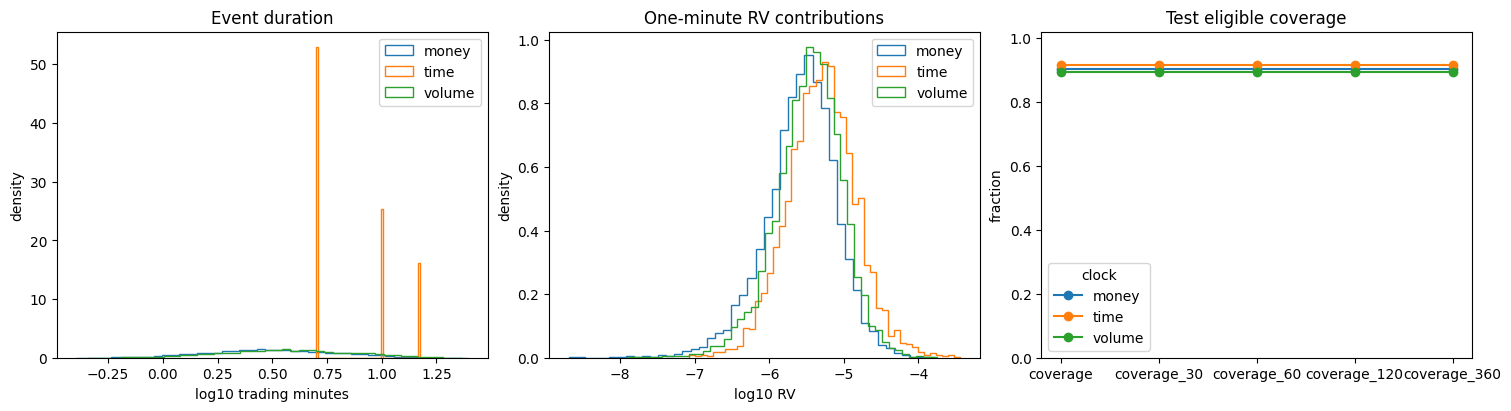

坐标积分、贡献缺失传播、100个15分钟标签切片核对、源键及BPV兼容性检查均通过。


In [5]:
# 6a. 分轴/粒度/训练测试段统计资格。
# coverage只检查区间本身；coverage_L还要求对应L的历史季节因子有限且为正。
coverage_frames = []
reason_frames = []
for fold_id, events_df in events_by_fold.items():
    for (clock, equivalent_minutes, split), group_df in events_df.groupby(["clock","equivalent_minutes","split"], observed=True):
        coverage_frames.append({"fold_id":fold_id,"clock":clock,"equivalent_minutes":equivalent_minutes,"split":split,
            "rows":len(group_df),"eligible":int(group_df["eligible"].sum()),"coverage":float(group_df["eligible"].mean()),
            **{f"coverage_{lookback}":float((group_df["eligible"] & np.isfinite(group_df[f"seasonality_{lookback}"])
                & group_df[f"seasonality_{lookback}"].gt(0)).mean()) for lookback in LOOKBACKS}})
    # 一个事件可能命中多个原因，因此原因条数之和可能超过不合格事件数。
    reasons = events_df.loc[~events_df["eligible"],"exclusion_reason"].str.split(";").explode().value_counts()
    reason_frames.extend({"fold_id":fold_id,"reason":reason,"rows":int(count)} for reason,count in reasons.items())
coverage_df = pd.DataFrame(coverage_frames)
exclusion_df = pd.DataFrame(reason_frames)
display(coverage_df)
display(exclusion_df)
# 6b. 图只取一个fold的测试段合格事件；默认展示final_2026。
# 正RV取log10仅用于绘图，不删除表中的真实零值或改变后续模型输入。
plot_fold = "final_2026" if "final_2026" in events_by_fold else selected_folds[-1]
plot_df = events_by_fold[plot_fold]
plot_df = plot_df.loc[plot_df["split"].eq("test") & plot_df["eligible"]]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for clock, group_df in plot_df.groupby("clock", observed=True):
    axes[0].hist(np.log10(group_df["trading_duration_minutes"]), bins=45, histtype="step", density=True, label=clock)
    positive_rv = group_df.loc[group_df["rv"]>0,"rv"]
    axes[1].hist(np.log10(positive_rv), bins=45, histtype="step", density=True, label=clock)
# 6c. 覆盖图对配置比例作描述性平均；不是全样本加权覆盖率或预测排名。
plot_coverage_df = coverage_df.loc[coverage_df["split"].eq("test")]
plot_coverage_df.groupby("clock",observed=True)[["coverage", *[f"coverage_{x}" for x in LOOKBACKS]]].mean().T.plot(ax=axes[2],marker="o")
axes[0].set(xlabel="log10 trading minutes",ylabel="density",title="Event duration")
axes[1].set(xlabel="log10 RV",ylabel="density",title="One-minute RV contributions")
axes[2].set(title="Test eligible coverage",ylabel="fraction",ylim=(0,1.02))
for ax in axes[:2]: ax.legend()
plt.show()
print("坐标积分、贡献缺失传播、100个15分钟标签切片核对、源键及BPV兼容性检查均通过。")

## 7. 构造完成

下方报告的是上一次构造调用的耗时。公共表留在当前内存中；后续拟合和预测Notebook加载本书的标记定义单元，再调用相同入口重建输入。

In [6]:
# 这里汇报第4节调用的完成情况，不会再次构造观测量。
print(f"观测量及03历史时钟重建完成，累计 {manifest['elapsed_seconds']:.2f} 秒。")
print("未生成中间数据文件。后续Notebook加载observation-kernel并调用build_volatility_observations即可重建。")

观测量及03历史时钟重建完成，累计 21.51 秒。
未生成中间数据文件。后续Notebook加载observation-kernel并调用build_volatility_observations即可重建。
